In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn.linear_model as sklin
import sklearn.model_selection as skms
import sklearn.metrics as skmet
import sklearn.preprocessing as skpre
import sklearn.svm as sksvm

In [2]:
dataset = pd.read_csv("../data/SampleRegressionDataset.csv")
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# StandardScalar requires a 2d array, so use reshape() to convert y
y = y.reshape(-1, 1)

In [3]:
x_train, x_test, y_train, y_test = skms.train_test_split(x, y, test_size=0.2)

In [4]:
# Apply feature scaling
scalar_x = skpre.StandardScaler()
scalar_y = skpre.StandardScaler()

x_train_sc = scalar_x.fit_transform(x_train)
y_train_sc = scalar_y.fit_transform(y_train)

In [5]:
regressor = sksvm.SVR(kernel='rbf')
regressor.fit(x_train_sc, y_train_sc)

c:\Users\madam\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

In [6]:
x_test_sc = scalar_x.transform(x_test)

y_pred = scalar_y.inverse_transform(regressor.predict(x_test_sc).reshape(-1, 1))

In [7]:
skmet.r2_score(y_true=y_test, y_pred=y_pred)

0.9438578419574238

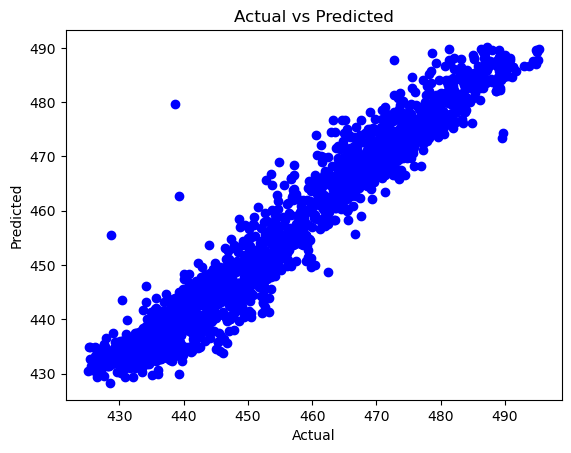

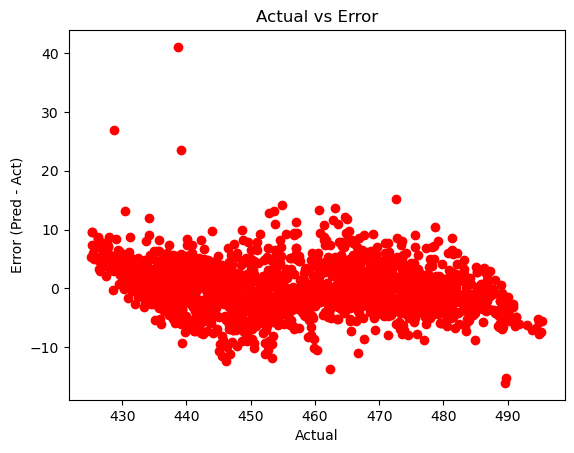

In [8]:
plt.scatter(y_test, y_pred, color="blue")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()
plt.scatter(y_test, y_pred-y_test, color="red")
plt.title("Actual vs Error")
plt.xlabel("Actual")
plt.ylabel("Error (Pred - Act)")
plt.show()